# Первые эксперименты по обучению nanoGPT со спарсными активациями

Цель на этом этапе — получить осмысленный первый экспериментальный артефакт с измеримыми результатами.

Сделали следующее:

1. подготовили маленький датасет для посимвольного языкового моделирования,
2. обучили dense-бейзлайн трансформера,
3. обучили sparse-вариант, где в FFN активны только top-k каналов,
4. сравнили сравнение в более тяжелой конфигурации с длинным контекстом,
5. сравнили loss, throughput и потребление памяти.

## Постановка эксперимента

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
device

'cuda'

## Данные

Для первых экспериментов используется корпус Tiny Shakespeare. Это стандартный достаточно большой датасет для быстрых экспериментов по языковому моделированию

In [2]:
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
text_path = data_dir / 'tiny_shakespeare.txt'

if not text_path.exists():
    text = requests.get('https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt', timeout=30).text
    text_path.write_text(text)

text = text_path.read_text()
chars = sorted(list(set(text)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

len(text), len(chars), train_data.shape, val_data.shape

(1115394, 65, torch.Size([1003854]), torch.Size([111540]))

## Семейство моделей

В качестве бейзлайна используем компактный GPT-подобный трансформер. Sparse-вариант отличается только FFN-блоком: после первой линейной проекции для каждого токена активными остаются только top-k каналов по модулю активации. Это простое первое приближение к спарсификации активаций. Реализация специально сделана через dense-операции PyTorch, чтобы на первом этапе отделить эффект самой идеи от kernel-level оптимизации.

In [3]:
dropout = 0.1
vocab_size = len(chars)
ffn_mult = 4
sparsity_ratio = 0.75

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=dropout if self.training else 0.0)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.proj(y))
        return y

class DenseMLP(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        hidden = ffn_mult * n_embd
        self.fc = nn.Linear(n_embd, hidden)
        self.proj = nn.Linear(hidden, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc(x)
        x = F.gelu(x)
        x = self.proj(x)
        x = self.dropout(x)
        return x

class SparseMLP(nn.Module):
    def __init__(self, n_embd, sparsity_ratio):
        super().__init__()
        hidden = ffn_mult * n_embd
        self.keep = max(1, int(hidden * (1 - sparsity_ratio)))
        self.fc = nn.Linear(n_embd, hidden)
        self.proj = nn.Linear(hidden, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc(x)
        x = F.gelu(x)
        _, indices = torch.topk(x.abs(), k=self.keep, dim=-1)
        mask = torch.zeros_like(x)
        mask.scatter_(-1, indices, 1.0)
        x = x * mask
        x = self.proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):
    def __init__(self, n_embd, n_head, sparse=False, sparsity_ratio=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = SparseMLP(n_embd, sparsity_ratio) if sparse else DenseMLP(n_embd)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, block_size, n_embd, n_head, n_layer, sparse=False, sparsity_ratio=0.0):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, sparse=sparse, sparsity_ratio=sparsity_ratio) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.token_emb(idx) + self.pos_emb(pos)[None, :, :]
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

## Эксперимент 1: short-context бейзлайн

Первое сравнение проверяет, остается ли sparse-приближение вообще обучаемым в умеренной конфигурации

In [4]:
experiment_name = 'short_context'
batch_size = 32
block_size = 128
n_embd = 192
n_head = 6
n_layer = 4
steps = 120
eval_interval = 20
lr = 3e-4

results = []

for name, sparse_flag in [('dense', False), ('sparse', True)]:
    model = TinyGPT(block_size=block_size, n_embd=n_embd, n_head=n_head, n_layer=n_layer, sparse=sparse_flag, sparsity_ratio=sparsity_ratio).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    start = time.time()
    progress = tqdm(range(1, steps + 1), desc=f'{experiment_name}:{name}', leave=False)
    for step in progress:
        ix = torch.randint(len(train_data) - block_size - 1, (batch_size,))
        xb = torch.stack([train_data[i:i + block_size] for i in ix]).to(device)
        yb = torch.stack([train_data[i + 1:i + block_size + 1] for i in ix]).to(device)
        model.train()
        optimizer.zero_grad(set_to_none=True)
        _, loss = model(xb, yb)
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                ix_val = torch.randint(len(val_data) - block_size - 1, (batch_size,))
                xval = torch.stack([val_data[i:i + block_size] for i in ix_val]).to(device)
                yval = torch.stack([val_data[i + 1:i + block_size + 1] for i in ix_val]).to(device)
                _, val_loss = model(xval, yval)
            progress.set_postfix(train_loss=f'{loss.item():.3f}', val_loss=f'{val_loss.item():.3f}')
            results.append({
                'experiment': experiment_name,
                'model': name,
                'step': step,
                'train_loss': loss.item(),
                'val_loss': val_loss.item()
            })
    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start
    peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
    tokens_processed = steps * batch_size * block_size
    results.append({
        'experiment': experiment_name,
        'model': name,
        'step': 'summary',
        'train_loss': float('nan'),
        'val_loss': float('nan'),
        'elapsed_sec': elapsed,
        'tokens_per_sec': tokens_processed / elapsed,
        'peak_memory_mb': peak_memory_mb
    })

results_df = pd.DataFrame(results)
results_df

short_context:dense:   0%|          | 0/120 [00:00<?, ?it/s]

short_context:sparse:   0%|          | 0/120 [00:00<?, ?it/s]

,experiment,model,step,train_loss,val_loss,elapsed_sec,tokens_per_sec,peak_memory_mb
0,short_context,dense,1,4.301603,4.095449,NaN,NaN,NaN
1,short_context,dense,20,3.019353,3.066434,NaN,NaN,NaN
2,short_context,dense,40,2.805069,2.728816,NaN,NaN,NaN
3,short_context,dense,60,2.688743,2.625922,NaN,NaN,NaN
4,short_context,dense,80,2.578394,2.594366,NaN,NaN,NaN
5,short_context,dense,100,2.562107,2.571986,NaN,NaN,NaN
6,short_context,dense,120,2.568209,2.561136,NaN,NaN,NaN
7,short_context,dense,summary,NaN,NaN,3.599376,136557.013655,262.684570
8,short_context,sparse,1,4.352662,4.144049,NaN,NaN,NaN
9,short_context,sparse,20,3.073329,3.125726,NaN,NaN,NaN


Результат short-context эксперимента уже сам по себе осмысленный. Обе модели обучаются стабильно и сходятся к очень близкому значению validation loss. Dense-бейзлайн заканчивает с validation loss около 2.56, а sparse-вариант достигает примерно 2.53. При этом sparse PyTorch-прокси уже на этой легкой конфигурации остается менее эффективным: throughput падает примерно со 136.6k до 126.1k tokens/sec, а peak memory растет примерно с 262.7 MB до 314.8 MB. Это нормально для dense-backed реализации через torch. Именно этот разрыв и мотивирует следующий этап проекта со специализированными kernels.

## Эксперимент 2: более тяжелая longer-context конфигурация

Сравнение повторяется в более тяжелой конфигурации с большим контекстом, большим hidden size и большим числом слоев. Проверим, сохраняется ли тот же качественный паттерн в заметно более тяжелом режиме обучения.

In [5]:
experiment_name = 'longer_context'
batch_size = 24
block_size = 256
n_embd = 256
n_head = 8
n_layer = 6
steps = 160
eval_interval = 20
lr = 3e-4

for name, sparse_flag in [('dense', False), ('sparse', True)]:
    model = TinyGPT(block_size=block_size, n_embd=n_embd, n_head=n_head, n_layer=n_layer, sparse=sparse_flag, sparsity_ratio=sparsity_ratio).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    start = time.time()
    progress = tqdm(range(1, steps + 1), desc=f'{experiment_name}:{name}', leave=False)
    for step in progress:
        ix = torch.randint(len(train_data) - block_size - 1, (batch_size,))
        xb = torch.stack([train_data[i:i + block_size] for i in ix]).to(device)
        yb = torch.stack([train_data[i + 1:i + block_size + 1] for i in ix]).to(device)
        model.train()
        optimizer.zero_grad(set_to_none=True)
        _, loss = model(xb, yb)
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                ix_val = torch.randint(len(val_data) - block_size - 1, (batch_size,))
                xval = torch.stack([val_data[i:i + block_size] for i in ix_val]).to(device)
                yval = torch.stack([val_data[i + 1:i + block_size + 1] for i in ix_val]).to(device)
                _, val_loss = model(xval, yval)
            progress.set_postfix(train_loss=f'{loss.item():.3f}', val_loss=f'{val_loss.item():.3f}')
            results.append({
                'experiment': experiment_name,
                'model': name,
                'step': step,
                'train_loss': loss.item(),
                'val_loss': val_loss.item()
            })
    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start
    peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
    tokens_processed = steps * batch_size * block_size
    results.append({
        'experiment': experiment_name,
        'model': name,
        'step': 'summary',
        'train_loss': float('nan'),
        'val_loss': float('nan'),
        'elapsed_sec': elapsed,
        'tokens_per_sec': tokens_processed / elapsed,
        'peak_memory_mb': peak_memory_mb
    })

results_df = pd.DataFrame(results)
results_df

longer_context:dense:   0%|          | 0/160 [00:00<?, ?it/s]

longer_context:sparse:   0%|          | 0/160 [00:00<?, ?it/s]

,experiment,model,step,train_loss,val_loss,elapsed_sec,tokens_per_sec,peak_memory_mb
0,short_context,dense,1,4.301603,4.095449,NaN,NaN,NaN
1,short_context,dense,20,3.019353,3.066434,NaN,NaN,NaN
2,short_context,dense,40,2.805069,2.728816,NaN,NaN,NaN
3,short_context,dense,60,2.688743,2.625922,NaN,NaN,NaN
4,short_context,dense,80,2.578394,2.594366,NaN,NaN,NaN
5,short_context,dense,100,2.562107,2.571986,NaN,NaN,NaN
6,short_context,dense,120,2.568209,2.561136,NaN,NaN,NaN
7,short_context,dense,summary,NaN,NaN,3.599376,136557.013655,262.684570
8,short_context,sparse,1,4.352662,4.144049,NaN,NaN,NaN
9,short_context,sparse,20,3.073329,3.125726,NaN,NaN,NaN


## Графики обучения



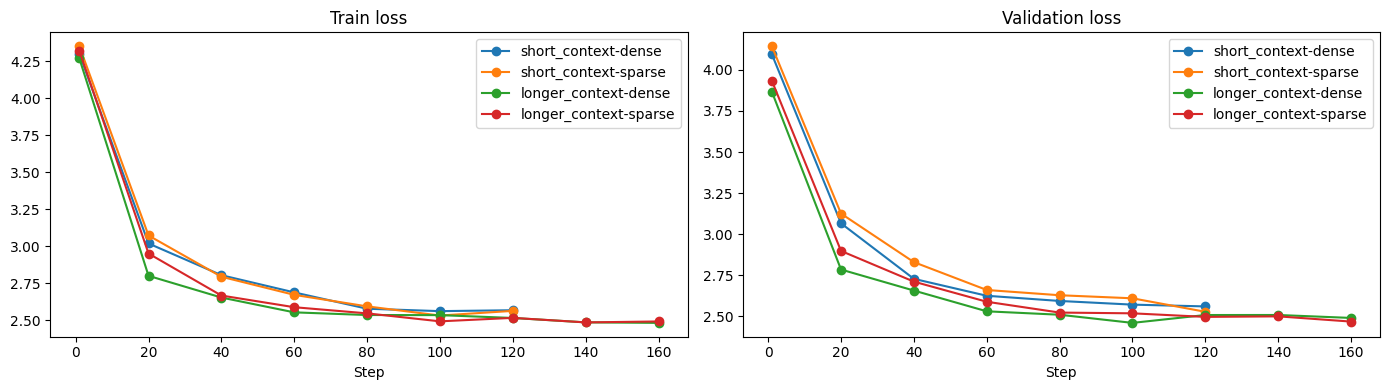

In [6]:
curve_df = results_df[results_df['step'] != 'summary'].copy()
curve_df['step'] = curve_df['step'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for experiment in curve_df['experiment'].unique():
    subset = curve_df[curve_df['experiment'] == experiment]
    for model_name in subset['model'].unique():
        part = subset[subset['model'] == model_name]
        axes[0].plot(part['step'], part['train_loss'], marker='o', label=f'{experiment}-{model_name}')
        axes[1].plot(part['step'], part['val_loss'], marker='o', label=f'{experiment}-{model_name}')
axes[0].set_title('Train loss')
axes[1].set_title('Validation loss')
axes[0].set_xlabel('Step')
axes[1].set_xlabel('Step')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

Первый вопрос состоит в том, остается ли sparse-вариант обучаемым и в легкой, и в более тяжелой конфигурации. По кривым видно, что ответ положительный: в short-context эксперименте dense-модель заканчивает с validation loss около 2.56, а sparse-модель около 2.53; в longer-context эксперименте dense-модель заканчивает около 2.49, а sparse-модель около 2.47. То есть даже в более тяжелом режиме sparse-вариант не ломает оптимизацию и приходит к сопоставимому, а местами даже чуть лучшему качеству.

## Сравнение эффективности

In [7]:
summary_df = results_df[results_df['step'] == 'summary'][['experiment', 'model', 'elapsed_sec', 'tokens_per_sec', 'peak_memory_mb']].reset_index(drop=True)
summary_df

,experiment,model,elapsed_sec,tokens_per_sec,peak_memory_mb
0,short_context,dense,3.599376,136557.013655,262.684570
1,short_context,sparse,3.896818,126133.683884,314.820312
2,longer_context,dense,12.460939,78889.718332,721.560547
3,longer_context,sparse,16.084497,61117.236152,872.993164


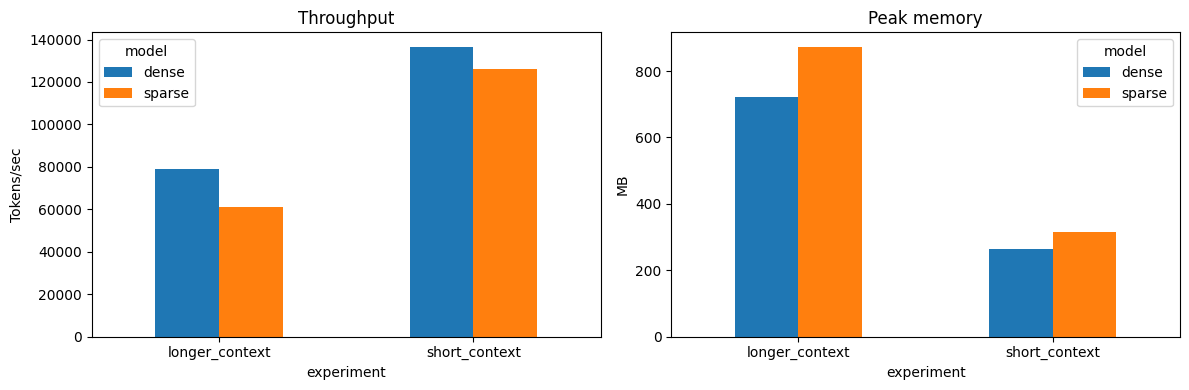

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
throughput_pivot = summary_df.pivot(index='experiment', columns='model', values='tokens_per_sec')
memory_pivot = summary_df.pivot(index='experiment', columns='model', values='peak_memory_mb')
throughput_pivot.plot(kind='bar', ax=axes[0], rot=0, title='Throughput')
axes[0].set_ylabel('Tokens/sec')
memory_pivot.plot(kind='bar', ax=axes[1], rot=0, title='Peak memory')
axes[1].set_ylabel('MB')
plt.tight_layout()
plt.show()

Второй вопрос состоит в том, меняет ли спарсификация время работы и потребление памяти еще до появления кастомных kernels. Ответ по результатам первого этапа тоже однозначный: при vanilla PyTorch masking спарсификация делает обучение и медленнее, и тяжелее по памяти в обеих конфигурациях. В short-context режиме throughput падает примерно со 136.6k до 126.1k tokens/sec, а peak memory растет с 262.7 MB до 314.8 MB. В longer-context режиме штраф становится еще заметнее: throughput падает примерно с 78.9k до 61.1k tokens/sec, а peak memory растет с 721.6 MB до 873.0 MB. Таким образо, мы отделяем идею спарсификации от системной эффективности и задаем конкретную цель для будущей kernel-оптимизации.

## Эксперимент 3: Абляция по уровню спарсности

Проверим, как качество и эффективность зависят от значения `sparsity_ratio`. Запустим несколько sparse-вариантов с уровнями 0.25, 0.5, 0.75 и 0.9 на базе short-context конфигурации.

In [9]:
experiment_name = 'sparsity_ablation'
batch_size = 32
block_size = 128
n_embd = 192
n_head = 6
n_layer = 4
steps = 120
eval_interval = 20
lr = 3e-4

sparsity_ratios = [0.25, 0.5, 0.75, 0.9]
results_sparsity = []

for ratio in sparsity_ratios:
    name = f'sparse_{ratio}'
    model = TinyGPT(block_size=block_size, n_embd=n_embd, n_head=n_head, n_layer=n_layer, sparse=True, sparsity_ratio=ratio).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    start = time.time()
    progress = tqdm(range(1, steps + 1), desc=f'{experiment_name}:{name}', leave=False)
    for step in progress:
        ix = torch.randint(len(train_data) - block_size - 1, (batch_size,))
        xb = torch.stack([train_data[i:i + block_size] for i in ix]).to(device)
        yb = torch.stack([train_data[i + 1:i + block_size + 1] for i in ix]).to(device)
        model.train()
        optimizer.zero_grad(set_to_none=True)
        _, loss = model(xb, yb)
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == 1:
            model.eval()
            with torch.no_grad():
                ix_val = torch.randint(len(val_data) - block_size - 1, (batch_size,))
                xval = torch.stack([val_data[i:i + block_size] for i in ix_val]).to(device)
                yval = torch.stack([val_data[i + 1:i + block_size + 1] for i in ix_val]).to(device)
                _, val_loss = model(xval, yval)
            progress.set_postfix(train_loss=f'{loss.item():.3f}', val_loss=f'{val_loss.item():.3f}')
            results_sparsity.append({
                'experiment': experiment_name,
                'model': name,
                'step': step,
                'train_loss': loss.item(),
                'val_loss': val_loss.item()
            })
    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start
    peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
    tokens_processed = steps * batch_size * block_size
    results_sparsity.append({
        'experiment': experiment_name,
        'model': name,
        'step': 'summary',
        'train_loss': float('nan'),
        'val_loss': float('nan'),
        'elapsed_sec': elapsed,
        'tokens_per_sec': tokens_processed / elapsed,
        'peak_memory_mb': peak_memory_mb
    })

results_sparsity_df = pd.DataFrame(results_sparsity)
results_sparsity_df[results_sparsity_df['step'] == 'summary']

sparsity_ablation:sparse_0.25:   0%|          | 0/120 [00:00<?, ?it/s]

sparsity_ablation:sparse_0.5:   0%|          | 0/120 [00:00<?, ?it/s]

sparsity_ablation:sparse_0.75:   0%|          | 0/120 [00:00<?, ?it/s]

sparsity_ablation:sparse_0.9:   0%|          | 0/120 [00:00<?, ?it/s]

,experiment,model,step,train_loss,val_loss,elapsed_sec,tokens_per_sec,peak_memory_mb
7,sparsity_ablation,sparse_0.25,summary,NaN,NaN,4.139915,118727.082454,354.453125
15,sparsity_ablation,sparse_0.5,summary,NaN,NaN,3.971007,123777.164469,322.820312
23,sparsity_ablation,sparse_0.75,summary,NaN,NaN,3.921188,125349.755116,313.820312
31,sparsity_ablation,sparse_0.9,summary,NaN,NaN,3.645028,134846.705357,310.684570


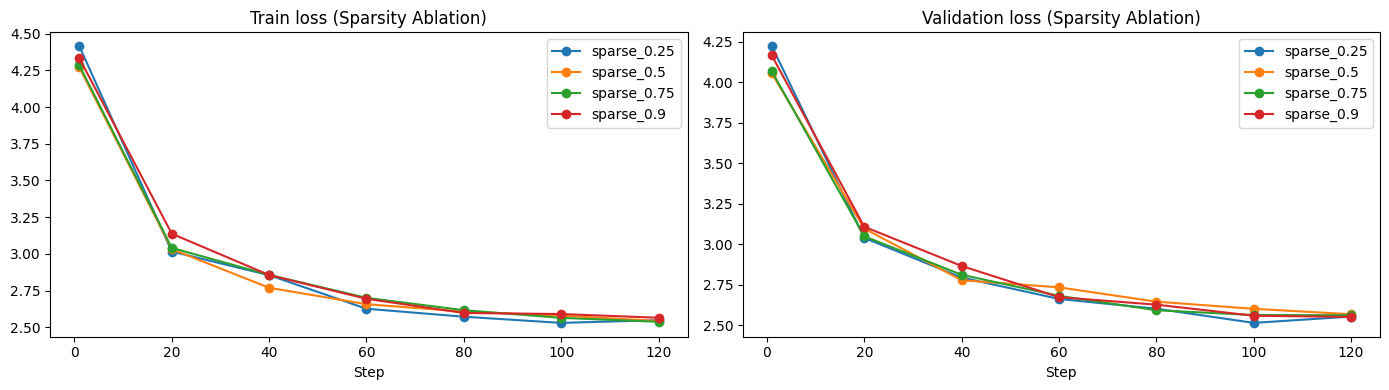

In [10]:
curve_df = results_sparsity_df[results_sparsity_df['step'] != 'summary'].copy()
curve_df['step'] = curve_df['step'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for model_name in curve_df['model'].unique():
    part = curve_df[curve_df['model'] == model_name]
    axes[0].plot(part['step'], part['train_loss'], marker='o', label=model_name)
    axes[1].plot(part['step'], part['val_loss'], marker='o', label=model_name)
axes[0].set_title('Train loss (Sparsity Ablation)')
axes[1].set_title('Validation loss (Sparsity Ablation)')
axes[0].set_xlabel('Step')
axes[1].set_xlabel('Step')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

## Эксперимент 4: Масштабирование по длине контекста

Проверим несколько значений `block_size` (128, 256, 512), чтобы посмотреть, как растет потребление памяти и сохраняется ли обучаемость sparse-варианта на более длинном контексте.

In [11]:
experiment_name = 'block_size_scaling'
batch_size = 16
block_sizes = [128, 256, 512]
n_embd = 192
n_head = 6
n_layer = 4
steps = 120
eval_interval = 20
lr = 3e-4
sparsity_ratio = 0.75

results_context = []

for b_size in block_sizes:
    for name, sparse_flag in [('dense', False), ('sparse', True)]:
        model_name = f'{name}_{b_size}'
        model = TinyGPT(block_size=b_size, n_embd=n_embd, n_head=n_head, n_layer=n_layer, sparse=sparse_flag, sparsity_ratio=sparsity_ratio).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        if device == 'cuda':
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
        start = time.time()
        progress = tqdm(range(1, steps + 1), desc=f'{experiment_name}:{model_name}', leave=False)
        for step in progress:
            ix = torch.randint(len(train_data) - b_size - 1, (batch_size,))
            xb = torch.stack([train_data[i:i + b_size] for i in ix]).to(device)
            yb = torch.stack([train_data[i + 1:i + b_size + 1] for i in ix]).to(device)
            model.train()
            optimizer.zero_grad(set_to_none=True)
            _, loss = model(xb, yb)
            loss.backward()
            optimizer.step()

            if step % eval_interval == 0 or step == 1:
                model.eval()
                with torch.no_grad():
                    ix_val = torch.randint(len(val_data) - b_size - 1, (batch_size,))
                    xval = torch.stack([val_data[i:i + b_size] for i in ix_val]).to(device)
                    yval = torch.stack([val_data[i + 1:i + b_size + 1] for i in ix_val]).to(device)
                    _, val_loss = model(xval, yval)
                progress.set_postfix(train_loss=f'{loss.item():.3f}', val_loss=f'{val_loss.item():.3f}')
                results_context.append({
                    'experiment': experiment_name,
                    'model': model_name,
                    'block_size': b_size,
                    'is_sparse': sparse_flag,
                    'step': step,
                    'train_loss': loss.item(),
                    'val_loss': val_loss.item()
                })
        if device == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.time() - start
        peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
        tokens_processed = steps * batch_size * b_size
        results_context.append({
            'experiment': experiment_name,
            'model': model_name,
            'block_size': b_size,
            'is_sparse': sparse_flag,
            'step': 'summary',
            'train_loss': float('nan'),
            'val_loss': float('nan'),
            'elapsed_sec': elapsed,
            'tokens_per_sec': tokens_processed / elapsed,
            'peak_memory_mb': peak_memory_mb
        })

results_context_df = pd.DataFrame(results_context)
results_context_df[results_context_df['step'] == 'summary']

block_size_scaling:dense_128:   0%|          | 0/120 [00:00<?, ?it/s]

block_size_scaling:sparse_128:   0%|          | 0/120 [00:00<?, ?it/s]

block_size_scaling:dense_256:   0%|          | 0/120 [00:00<?, ?it/s]

block_size_scaling:sparse_256:   0%|          | 0/120 [00:00<?, ?it/s]

block_size_scaling:dense_512:   0%|          | 0/120 [00:00<?, ?it/s]

block_size_scaling:sparse_512:   0%|          | 0/120 [00:00<?, ?it/s]

,experiment,model,block_size,is_sparse,step,train_loss,val_loss,elapsed_sec,tokens_per_sec,peak_memory_mb
7,block_size_scaling,dense_128,128,False,summary,NaN,NaN,1.628425,150918.799276,150.333008
15,block_size_scaling,sparse_128,128,True,summary,NaN,NaN,2.120921,115874.194272,175.593750
23,block_size_scaling,dense_256,256,False,summary,NaN,NaN,3.108877,158102.108549,262.966797
31,block_size_scaling,sparse_256,256,True,summary,NaN,NaN,4.187752,117370.860303,314.102539
39,block_size_scaling,dense_512,512,False,summary,NaN,NaN,7.063112,139179.448143,488.546875
47,block_size_scaling,sparse_512,512,True,summary,NaN,NaN,9.196479,106893.088343,592.057617


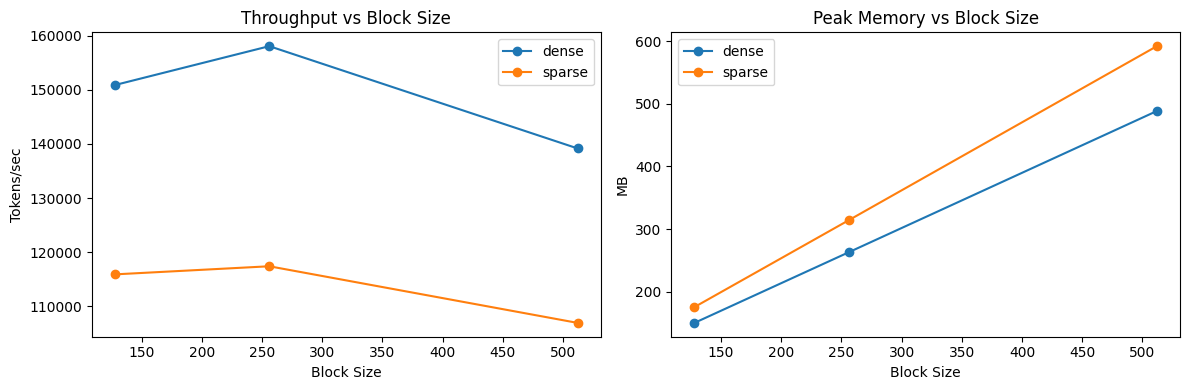

In [12]:
summary_ctx = results_context_df[results_context_df['step'] == 'summary'].copy()
summary_ctx['type'] = summary_ctx['is_sparse'].map({True: 'sparse', False: 'dense'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mtype in ['dense', 'sparse']:
    part = summary_ctx[summary_ctx['type'] == mtype]
    axes[0].plot(part['block_size'], part['tokens_per_sec'], marker='o', label=mtype)
    axes[1].plot(part['block_size'], part['peak_memory_mb'], marker='o', label=mtype)
axes[0].set_title('Throughput vs Block Size')
axes[0].set_xlabel('Block Size')
axes[0].set_ylabel('Tokens/sec')
axes[0].legend()
axes[1].set_title('Peak Memory vs Block Size')
axes[1].set_xlabel('Block Size')
axes[1].set_ylabel('MB')
axes[1].legend()
plt.tight_layout()
plt.show()

## Эксперимент 5: Масштабирование по размеру модели

Сравним текущую конфигурацию с более крупными за счет увеличения `n_embd` и `n_layer`, чтобы оценить, как масштабируется цена sparse-прокси по времени и памяти.

In [13]:
experiment_name = 'model_size_scaling'
batch_size = 16
block_size = 256
steps = 120
eval_interval = 20
lr = 3e-4
sparsity_ratio = 0.75

configs = [
    {'name': 'small', 'n_embd': 192, 'n_head': 6, 'n_layer': 4},
    {'name': 'medium', 'n_embd': 256, 'n_head': 8, 'n_layer': 6},
    {'name': 'large', 'n_embd': 384, 'n_head': 6, 'n_layer': 6}
]

results_size = []

for config in configs:
    for name, sparse_flag in [('dense', False), ('sparse', True)]:
        model_name = f"{config['name']}_{name}"
        model = TinyGPT(block_size=block_size, n_embd=config['n_embd'], n_head=config['n_head'], n_layer=config['n_layer'], sparse=sparse_flag, sparsity_ratio=sparsity_ratio).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        if device == 'cuda':
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
        start = time.time()
        progress = tqdm(range(1, steps + 1), desc=f'{experiment_name}:{model_name}', leave=False)
        for step in progress:
            ix = torch.randint(len(train_data) - block_size - 1, (batch_size,))
            xb = torch.stack([train_data[i:i + block_size] for i in ix]).to(device)
            yb = torch.stack([train_data[i + 1:i + block_size + 1] for i in ix]).to(device)
            model.train()
            optimizer.zero_grad(set_to_none=True)
            _, loss = model(xb, yb)
            loss.backward()
            optimizer.step()

            if step % eval_interval == 0 or step == 1:
                model.eval()
                with torch.no_grad():
                    ix_val = torch.randint(len(val_data) - block_size - 1, (batch_size,))
                    xval = torch.stack([val_data[i:i + block_size] for i in ix_val]).to(device)
                    yval = torch.stack([val_data[i + 1:i + block_size + 1] for i in ix_val]).to(device)
                    _, val_loss = model(xval, yval)
                progress.set_postfix(train_loss=f'{loss.item():.3f}', val_loss=f'{val_loss.item():.3f}')
                results_size.append({
                    'experiment': experiment_name,
                    'model': model_name,
                    'size_config': config['name'],
                    'is_sparse': sparse_flag,
                    'step': step,
                    'train_loss': loss.item(),
                    'val_loss': val_loss.item()
                })
        if device == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.time() - start
        peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == 'cuda' else float('nan')
        tokens_processed = steps * batch_size * block_size
        results_size.append({
            'experiment': experiment_name,
            'model': model_name,
            'size_config': config['name'],
            'is_sparse': sparse_flag,
            'step': 'summary',
            'train_loss': float('nan'),
            'val_loss': float('nan'),
            'elapsed_sec': elapsed,
            'tokens_per_sec': tokens_processed / elapsed,
            'peak_memory_mb': peak_memory_mb
        })

results_size_df = pd.DataFrame(results_size)
results_size_df[results_size_df['step'] == 'summary']

model_size_scaling:small_dense:   0%|          | 0/120 [00:00<?, ?it/s]

model_size_scaling:small_sparse:   0%|          | 0/120 [00:00<?, ?it/s]

model_size_scaling:medium_dense:   0%|          | 0/120 [00:00<?, ?it/s]

model_size_scaling:medium_sparse:   0%|          | 0/120 [00:00<?, ?it/s]

model_size_scaling:large_dense:   0%|          | 0/120 [00:00<?, ?it/s]

model_size_scaling:large_sparse:   0%|          | 0/120 [00:00<?, ?it/s]

,experiment,model,size_config,is_sparse,step,train_loss,val_loss,elapsed_sec,tokens_per_sec,peak_memory_mb
7,model_size_scaling,small_dense,small,False,summary,NaN,NaN,3.221796,152560.879372,262.966797
15,model_size_scaling,small_sparse,small,True,summary,NaN,NaN,4.217268,116549.380633,314.102539
23,model_size_scaling,medium_dense,medium,False,summary,NaN,NaN,6.834300,71919.579165,504.794922
31,model_size_scaling,medium_sparse,medium,True,summary,NaN,NaN,8.742708,56220.564041,604.727539
39,model_size_scaling,large_dense,large,False,summary,NaN,NaN,12.692104,38726.438646,792.401367
47,model_size_scaling,large_sparse,large,True,summary,NaN,NaN,14.963868,32847.122361,941.988281


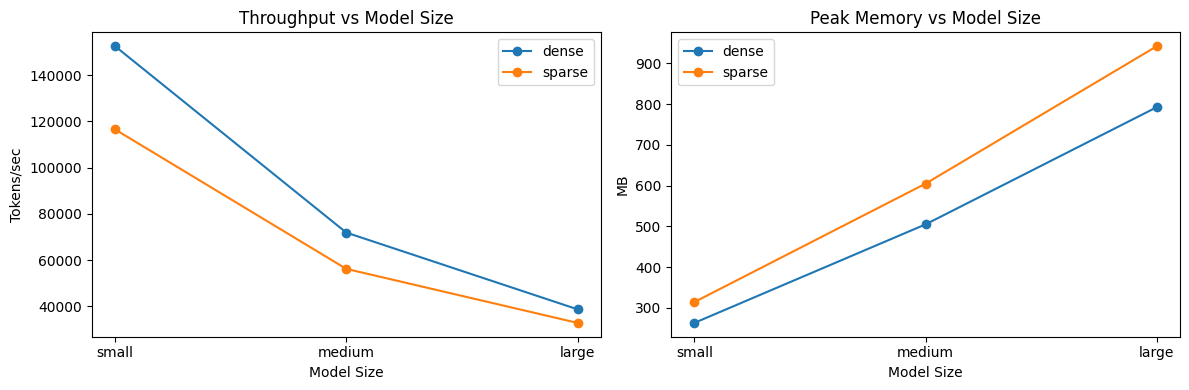

In [14]:
summary_size = results_size_df[results_size_df['step'] == 'summary'].copy()
summary_size['type'] = summary_size['is_sparse'].map({True: 'sparse', False: 'dense'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mtype in ['dense', 'sparse']:
    part = summary_size[summary_size['type'] == mtype]
    axes[0].plot(part['size_config'], part['tokens_per_sec'], marker='o', label=mtype)
    axes[1].plot(part['size_config'], part['peak_memory_mb'], marker='o', label=mtype)
axes[0].set_title('Throughput vs Model Size')
axes[0].set_xlabel('Model Size')
axes[0].set_ylabel('Tokens/sec')
axes[0].legend()
axes[1].set_title('Peak Memory vs Model Size')
axes[1].set_xlabel('Model Size')
axes[1].set_ylabel('MB')
axes[1].legend()
plt.tight_layout()
plt.show()

## Вывод по абляциям

Проведенные абляции подтверждают, что спарсная модель остается обучаемой при разных уровнях спарсности, длинах контекста и размерах модели. При этом во всех случаях наблюдается системный оверхед от наивной PyTorch-реализации (падение throughput и рост peak memory). Это окончательно формирует мотивацию для следующего этапа: разработки кастомных Triton-ядер для эффективного вычисления sparse FFN.

## Вывод по первым экспериментам

1. В коротком контексте dense- и sparse-модели обучаются очень похоже по качеству. Dense заканчивает примерно на validation loss 2.56, sparse — примерно на 2.53. Даже на наивной реализации через torch спарсификация не ломает обучение.
Системно sparse уже хуже dense: throughput падает примерно с 136.6k до 126.1k tokens/sec, а peak memory растет примерно с 262.7 MB до 314.8 MB. Значит, сама идея модельно жизнеспособна, но текущая реализация вычислительно неэффективна.

2. В более тяжелой конфигурации картина сохраняется. Dense приходит примерно к validation loss 2.49, sparse — примерно к 2.47. То есть при увеличении нагрузки sparse-вариант все еще остается обучаемым и не деградирует по качеству.
Но системный штраф становится заметнее: throughput падает примерно с 78.9k до 61.1k tokens/sec, а peak memory растет примерно с 721.6 MB до 873.0 MB. Это особенно важно, потому что именно long-context режим изначально и был основной мотивацией проекта. Пока что наивная sparse-реализация не помогает, а мешает.

3. По графикам абляции видно, что в диапазоне примерно 0.25–0.9 модель остается обучаемой во всех протестированных режимах спарсности. Кривые train/validation loss идут близко друг к другу, а к концу различия между вариантами небольшие.
Это означает, что top-k sparsification в FFN не является хрупкой идеей, работающей только в одной специально подобранной точке. Наоборот, есть целое семейство рабочих режимов. Дальше можно не спорить о том, работает ли сама идея, а переходить к вопросу, какой уровень спарсности дает лучший компромисс между качеством и стоимостью.

4. При росте длины контекста память растет у обеих моделей, что ожидаемо. Но sparse-вариант стабильно потребляет больше памяти, чем dense, и проигрывает по throughput на всех протестированных значениях `block_size`.
В текущем виде sparse FFN не дает системного выигрыша даже там, где интуитивно хотелось бы его увидеть — при росте контекста. Следовательно, bottleneck находится не в самой идее sparsity, а в способе ее реализации через torch.

5. При увеличении размера модели dense и sparse обе продолжают масштабироваться по качеству нормально, но sparse снова стабильно проигрывает по скорости и памяти. Причем с ростом модели этот разрыв не исчезает, а остается устойчивым.
Это означает, что проблема не локальна для одной маленькой конфигурации. Наоборот, текущая реализация имеет системный overhead, который переносится и на более крупные модели. Для защиты это очень хороший аргумент: показано, что проблема воспроизводится по нескольким осям масштабирования — по контексту, по размеру модели и по уровню спарсности.

## Заключение по первым экспериментам

На текущем этапе уже получен полноценный исследовательский результат:
- sparse FFN с top-k активациями обучаем;
- это верно и для короткого, и для более длинного контекста;
- это верно при разных уровнях спарсности;
- это верно при разных размерах модели;
- но наивная реализация через dense-backed masking системно неэффективна: она медленнее и требует больше памяти.

## План дальнейшей работы по проекту:

1. Реализация efficient sparse FFN вместо naive torch + dense masking.
2. Реализация custom forward/backward kernels для sparse FFN.
3. Полное сравнение dense / naive sparse / optimized sparse.
4. Long-context scaling после kernel-оптимизации.
5. Финальная абляция по sparcity_ratio уже на optimized реализации.
6. Итоговый анализ trade-off между quality, throughput и peak memory.

(На каждый из пунктов потребуется около 4 дней, что укладывается в срок до защиты)